### Audio automatic labeling

To do the labeling the features to extract the information are:
- Short-time Energy
- Envelope Detection
- Spectral Flux

The audio folder will serve as an intput of informations, then applying this three methods of feature extraction, the information regarding the sudden change on the audio .wav will be recorded into a csv file with information of the time and respective feature.

#### Scipy.signal
Hilbert transform: https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.hilbert.html

find_peaks: https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.find_peaks.html#scipy.signal.find_peaks

In [18]:
!pip install pandas

In [2]:
!pip install seaborn

In [3]:
import os
import librosa
import librosa.display
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, hilbert

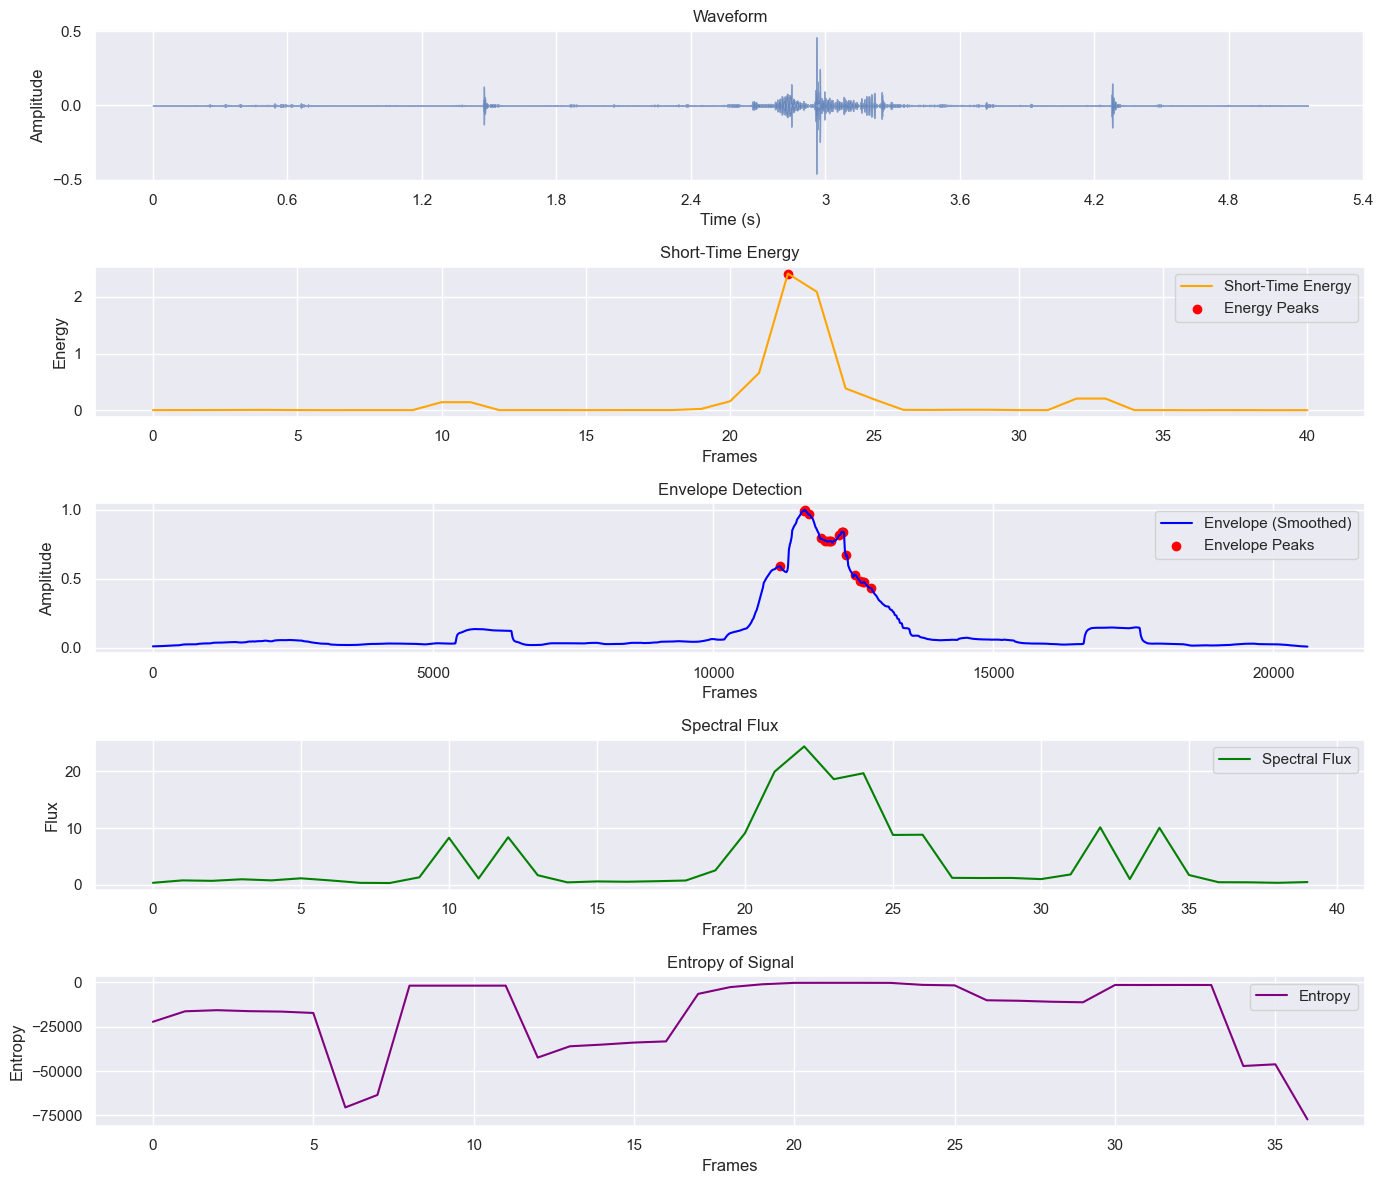

Detected Energy Peaks (frames): [22]
Detected Envelope Peaks (frames): [11190 11615 11631 11717 11921 12002 12034 12070 12087 12103 12246 12295
 12304 12325 12379 12524 12618 12677 12693 12816]


In [4]:
# Load the audio file
audio_path = r'C:\Users\Teresa\Desktop\MBBAS (2ºano)\Tese\Audio_samples\GC_F1-3ml.wav' 
y, sr = librosa.load(audio_path, sr=None)

# Set Seaborn style
sns.set(style="darkgrid")

# 1. Short-Time Energy (STE)
frame_length = 1024
hop_length = 512
energy = np.array([
    np.sum(np.abs(y[i:i+frame_length])**2)
    for i in range(0, len(y), hop_length)
])

# 2. Envelope Detection
envelope = np.abs(hilbert(y))
envelope_smoothed = librosa.util.normalize(np.convolve(envelope, np.ones(1000)/1000, mode='same'))

# 3. Spectral Flux
spectrogram = np.abs(librosa.stft(y, n_fft=2048, hop_length=hop_length))
spectral_flux = np.sqrt(np.sum(np.diff(spectrogram, axis=1)**2, axis=0))

# 4. Entropy Calculation
def entropy(signal):
    probability_distribution, _ = np.histogram(signal, bins=50, density=True)
    probability_distribution = probability_distribution[probability_distribution > 0]
    return -np.sum(probability_distribution * np.log2(probability_distribution))

window_size = 2048
entropy_values = [
    entropy(y[i:i+window_size])
    for i in range(0, len(y) - window_size, hop_length)
]

# 5. Find Peaks in Energy and Envelope
energy_peaks, _ = find_peaks(energy, height=np.mean(energy) + 1.5 * np.std(energy))
envelope_peaks, _ = find_peaks(envelope_smoothed, height=np.mean(envelope_smoothed) + 1.5 * np.std(envelope_smoothed))

# Plotting Results
plt.figure(figsize=(14, 12))

# 1. Waveform
plt.subplot(5, 1, 1)
librosa.display.waveshow(y, sr=sr, alpha=0.6)
plt.title("Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

# 2. Short-Time Energy (STE)
plt.subplot(5, 1, 2)
sns.lineplot(data=energy, color="orange", label="Short-Time Energy")
plt.scatter(energy_peaks, energy[energy_peaks], color="red", label="Energy Peaks")
plt.title("Short-Time Energy")
plt.xlabel("Frames")
plt.ylabel("Energy")
plt.legend()

# 3. Envelope
plt.subplot(5, 1, 3)
sns.lineplot(data=envelope_smoothed, color="blue", label="Envelope (Smoothed)")
plt.scatter(envelope_peaks, envelope_smoothed[envelope_peaks], color="red", label="Envelope Peaks")
plt.title("Envelope Detection")
plt.xlabel("Frames")
plt.ylabel("Amplitude")
plt.legend()

# 4. Spectral Flux
plt.subplot(5, 1, 4)
sns.lineplot(data=spectral_flux, color="green", label="Spectral Flux")
plt.title("Spectral Flux")
plt.xlabel("Frames")
plt.ylabel("Flux")
plt.legend()

# 5. Entropy
plt.subplot(5, 1, 5)
sns.lineplot(data=entropy_values, color="purple", label="Entropy")
plt.title("Entropy of Signal")
plt.xlabel("Frames")
plt.ylabel("Entropy")
plt.legend()

plt.tight_layout()
plt.show()

# Print Detected Peaks
print("Detected Energy Peaks (frames):", energy_peaks)
print("Detected Envelope Peaks (frames):", envelope_peaks)

### Test .wav files

- GC_F1_3ml

Deglutition event detected from 2.626s to 3.326s.


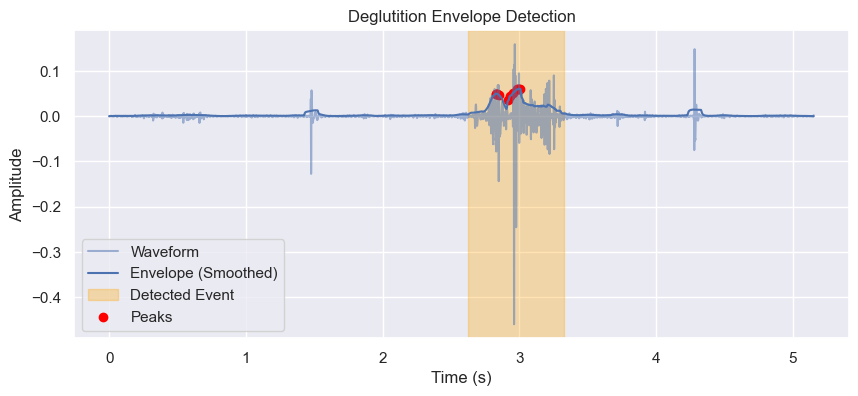

In [ ]:
# Load the audio file
audio_path = r'C:\Users\Teresa\Desktop\MBBAS (2ºano)\Tese\Audio_samples\GC_F1-3ml.wav' 
y, sr = librosa.load(audio_path, sr=None)  # Load with original sampling rate

# Set Seaborn style
sns.set(style="darkgrid")

# Compute envelope using the Hilbert transform
analytic_signal = scipy.signal.hilbert(y)
amplitude_envelope = np.abs(analytic_signal)

# Smooth the envelope with a moving average filter
window_size = int(sr * 0.1)  # 100ms window
smoothed_envelope = np.convolve(amplitude_envelope, np.ones(window_size)/window_size, mode='same')

# Detect peaks in the envelope
peaks, _ = scipy.signal.find_peaks(smoothed_envelope, height=np.max(smoothed_envelope) * 0.5)

# Convert peak indices to time values
peak_times = peaks / sr

# Extract start and end time of the deglutition event (assuming one main peak)
if len(peak_times) > 0:
    event_start = max(0, peak_times[0] - 0.2)  # 200ms before the peak
    event_end = min(len(y) / sr, peak_times[0] + 0.5)  # 500ms after the peak

    # Save to CSV
    df = pd.DataFrame({"Start_Time": [event_start], "End_Time": [event_end]})
    df.to_csv("deglutition_event.csv", index=False)

    print(f"Deglutition event detected from {event_start:.3f}s to {event_end:.3f}s.")

    # Plot waveform and envelope with highlighted event
    plt.figure(figsize=(10, 4))
    time_axis = np.linspace(0, len(y) / sr, len(y))

    sns.lineplot(x=time_axis, y=y, alpha=0.5, label="Waveform")
    sns.lineplot(x=time_axis, y=smoothed_envelope, color='b', label="Envelope (Smoothed)")
    
    # Highlight deglutition event
    plt.axvspan(event_start, event_end, color='orange', alpha=0.3, label="Detected Event")
    
    # Mark peaks
    plt.scatter(peak_times, [smoothed_envelope[peaks[i]] for i in range(len(peaks))], color='red', label="Peaks")

    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.title("Deglutition Envelope Detection")
    plt.show()
else:
    print("No clear deglutition event detected.")

##### Need to verify if the envelope detection can detect multiple swallow events

Deglutition event detected from 2.497s to 3.197s.


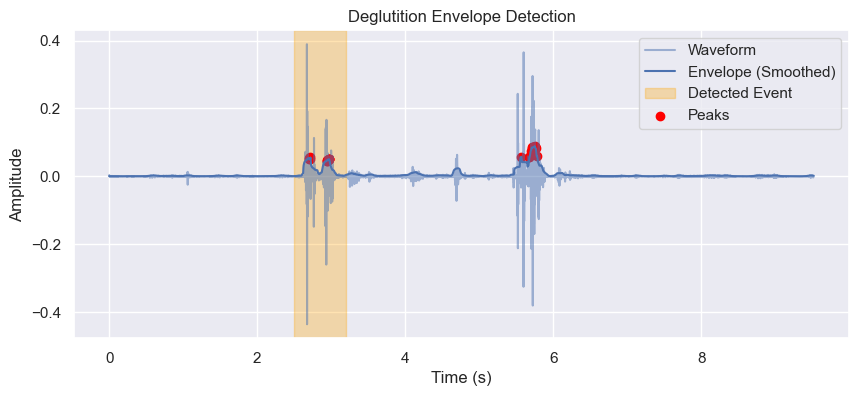

In [8]:
# Load the audio file
audio_path = r"C:\Users\Teresa\Desktop\MBBAS (2ºano)\Tese\Audio_samples\GC_F2_50ML.wav"
y, sr = librosa.load(audio_path, sr=None)

# Set Seaborn style
sns.set(style="darkgrid")

# Compute envelope using the Hilbert transform
analytic_signal = scipy.signal.hilbert(y)
amplitude_envelope = np.abs(analytic_signal)

# Smooth the envelope with a moving average filter
window_size = int(sr * 0.1)  # 100ms window
smoothed_envelope = np.convolve(amplitude_envelope, np.ones(window_size)/window_size, mode='same')

# Detect peaks in the envelope
peaks, _ = scipy.signal.find_peaks(smoothed_envelope, height=np.max(smoothed_envelope) * 0.5)
peak_times = peaks / sr

# Extract start and end time of the deglutition event (assuming one main peak)
if len(peak_times) > 0:
    event_start = max(0, peak_times[0] - 0.2)  # 200ms before the peak
    event_end = min(len(y) / sr, peak_times[0] + 0.5)  # 500ms after the peak

    # Save to CSV
    df = pd.DataFrame({"Start_Time": [event_start], "End_Time": [event_end]})
    df.to_csv("deglutition_event.csv", index=False)

    print(f"Deglutition event detected from {event_start:.3f}s to {event_end:.3f}s.")

    # Plot waveform and envelope with highlighted event
    plt.figure(figsize=(10, 4))
    time_axis = np.linspace(0, len(y) / sr, len(y))

    sns.lineplot(x=time_axis, y=y, alpha=0.5, label="Waveform")
    sns.lineplot(x=time_axis, y=smoothed_envelope, color='b', label="Envelope (Smoothed)")
    
    # Highlight deglutition event
    plt.axvspan(event_start, event_end, color='orange', alpha=0.3, label="Detected Event")
    
    # Mark peaks
    plt.scatter(peak_times, [smoothed_envelope[peaks[i]] for i in range(len(peaks))], color='red', label="Peaks")

    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.title("Deglutition Envelope Detection")
    plt.show()
else:
    print("No clear deglutition event detected.")


##### New updated code to detect multiple swallows

- GC-M6-50ML

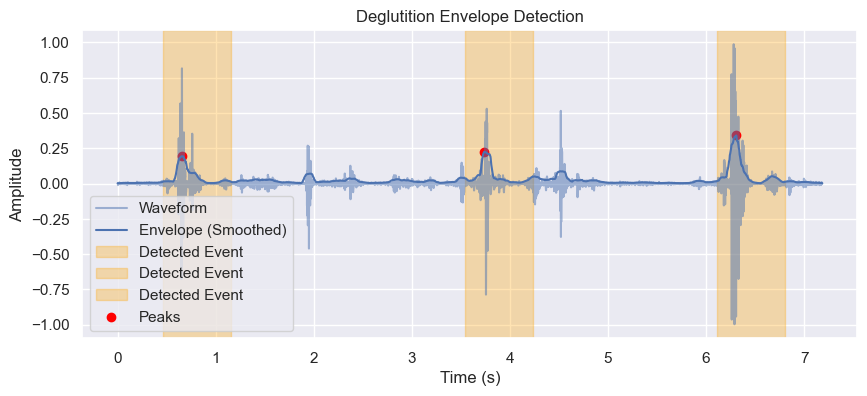

In [7]:
# Load the audio file
audio_path = r"C:\Users\Teresa\Desktop\MBBAS (2ºano)\Tese\Audio_samples\GC-Recortes\GC-M6-50ML.wav"
y, sr = librosa.load(audio_path, sr=None)

# Set Seaborn style
sns.set(style="darkgrid")

# Compute envelope using the Hilbert transform
analytic_signal = scipy.signal.hilbert(y)
amplitude_envelope = np.abs(analytic_signal)

# Smooth the envelope with a moving average filter
window_size = int(sr * 0.1)  # 100ms window
smoothed_envelope = np.convolve(amplitude_envelope, np.ones(window_size)/window_size, mode='same')

# Detect peaks in the envelope
peaks, _ = scipy.signal.find_peaks(smoothed_envelope, height=np.max(smoothed_envelope) * 0.4, distance=sr*0.5)
peak_times = peaks / sr

# Extract start and end times for each detected event
events = [(max(0, t - 0.2), min(len(y) / sr, t + 0.5)) for t in peak_times]

# ---- PLOT WAVEFORM ----
plt.figure(figsize=(10, 4))
time_axis = np.linspace(0, len(y) / sr, len(y))

sns.lineplot(x=time_axis, y=y, alpha=0.5, label="Waveform")
sns.lineplot(x=time_axis, y=smoothed_envelope, color='b', label="Envelope (Smoothed)")

# Highlight detected events
for start, end in events:
    plt.axvspan(start, end, color='orange', alpha=0.3, label="Detected Event")

# Mark detected peaks
plt.scatter(peak_times, smoothed_envelope[peaks], color='red', label="Peaks")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.title("Deglutition Envelope Detection")
plt.show()


- GC-F10-5ml

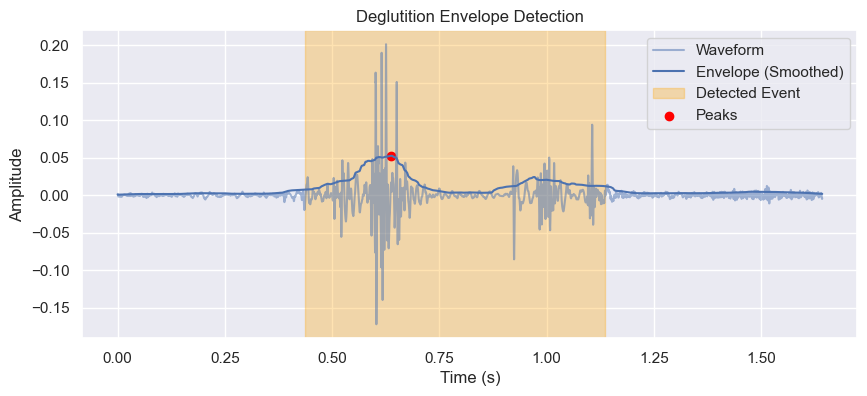

In [9]:
# Load the audio file
audio_path = r"C:\Users\Teresa\Desktop\MBBAS (2ºano)\Tese\Audio_samples\GC-Recortes\GC-F10-5ml.wav"
y, sr = librosa.load(audio_path, sr=None)

# Set Seaborn style
sns.set(style="darkgrid")

# Compute envelope using the Hilbert transform
analytic_signal = scipy.signal.hilbert(y)
amplitude_envelope = np.abs(analytic_signal)

# Smooth the envelope with a moving average filter
window_size = int(sr * 0.1)  # 100ms window
smoothed_envelope = np.convolve(amplitude_envelope, np.ones(window_size)/window_size, mode='same')

# Detect peaks in the envelope
peaks, _ = scipy.signal.find_peaks(smoothed_envelope, height=np.max(smoothed_envelope) * 0.4, distance=sr*0.5)
peak_times = peaks / sr

# Extract start and end times for each detected event
events = [(max(0, t - 0.2), min(len(y) / sr, t + 0.5)) for t in peak_times]

# Plot waveform and envelope with highlighted event
plt.figure(figsize=(10, 4))
time_axis = np.linspace(0, len(y) / sr, len(y))

sns.lineplot(x=time_axis, y=y, alpha=0.5, label="Waveform")
sns.lineplot(x=time_axis, y=smoothed_envelope, color='b', label="Envelope (Smoothed)")

# Highlight detected events
for start, end in events:
    plt.axvspan(start, end, color='orange', alpha=0.3, label="Detected Event")

# Mark detected peaks
plt.scatter(peak_times, smoothed_envelope[peaks], color='red', label="Peaks")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.title("Deglutition Envelope Detection")
plt.show()


#### Grupo experimental

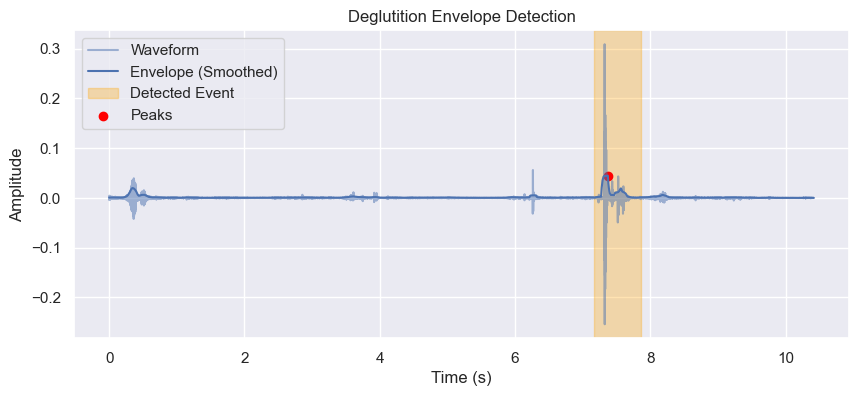

In [10]:
# Load the audio file
audio_path = r"C:\Users\Teresa\Desktop\MBBAS (2ºano)\Tese\Audio_samples\GE_F1_3ML.wav"
y, sr = librosa.load(audio_path, sr=None)

# Set Seaborn style
sns.set(style="darkgrid")

# Compute envelope using the Hilbert transform
analytic_signal = scipy.signal.hilbert(y)
amplitude_envelope = np.abs(analytic_signal)

# Smooth the envelope with a moving average filter
window_size = int(sr * 0.1)  # 100ms window
smoothed_envelope = np.convolve(amplitude_envelope, np.ones(window_size)/window_size, mode='same')

# Detect peaks in the envelope
peaks, _ = scipy.signal.find_peaks(smoothed_envelope, height=np.max(smoothed_envelope) * 0.5, distance=sr*0.5)
peak_times = peaks / sr

# Extract start and end times for each detected event
events = [(max(0, t - 0.2), min(len(y) / sr, t + 0.5)) for t in peak_times]

# Plot waveform and envelope with highlighted event
plt.figure(figsize=(10, 4))
time_axis = np.linspace(0, len(y) / sr, len(y))

sns.lineplot(x=time_axis, y=y, alpha=0.5, label="Waveform")
sns.lineplot(x=time_axis, y=smoothed_envelope, color='b', label="Envelope (Smoothed)")

# Highlight detected events
for start, end in events:
    plt.axvspan(start, end, color='orange', alpha=0.3, label="Detected Event")

# Mark detected peaks
plt.scatter(peak_times, smoothed_envelope[peaks], color='red', label="Peaks")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.title("Deglutition Envelope Detection")
plt.show()


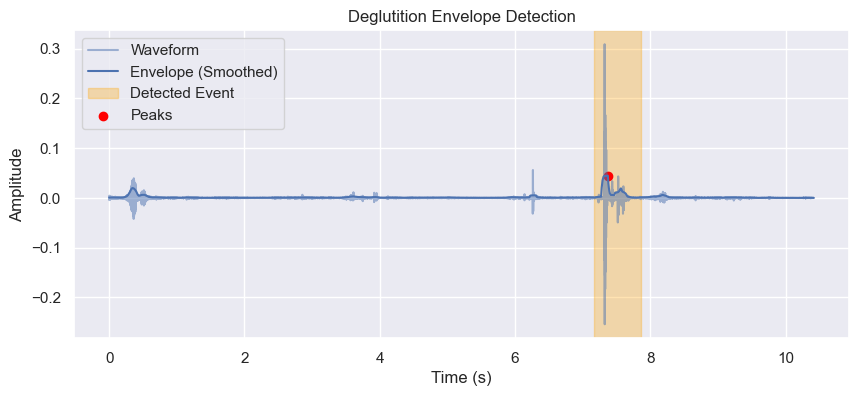

In [11]:
# Load the audio file
audio_path = r"C:\Users\Teresa\Desktop\MBBAS (2ºano)\Tese\Audio_samples\GE_F1_3ML.wav"
y, sr = librosa.load(audio_path, sr=None)

# Set Seaborn style
sns.set(style="darkgrid")

# Compute envelope using the Hilbert transform
analytic_signal = scipy.signal.hilbert(y)
amplitude_envelope = np.abs(analytic_signal)

# Smooth the envelope with a moving average filter
window_size = int(sr * 0.1)  # 100ms window
smoothed_envelope = np.convolve(amplitude_envelope, np.ones(window_size)/window_size, mode='same')

# Detect peaks in the envelope
peaks, _ = scipy.signal.find_peaks(smoothed_envelope, height=np.max(smoothed_envelope) * 0.5, distance=sr*0.5)
peak_times = peaks / sr

# Extract start and end times for each detected event
events = [(max(0, t - 0.2), min(len(y) / sr, t + 0.5)) for t in peak_times]

# Plot waveform and envelope with highlighted event
plt.figure(figsize=(10, 4))
time_axis = np.linspace(0, len(y) / sr, len(y))

sns.lineplot(x=time_axis, y=y, alpha=0.5, label="Waveform")
sns.lineplot(x=time_axis, y=smoothed_envelope, color='b', label="Envelope (Smoothed)")

# Highlight detected events
for start, end in events:
    plt.axvspan(start, end, color='orange', alpha=0.3, label="Detected Event")

# Mark detected peaks
plt.scatter(peak_times, smoothed_envelope[peaks], color='red', label="Peaks")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.title("Deglutition Envelope Detection")
plt.show()


____________________________________________________________________________________________________________________________________________

#### Plot from 0.5s pre and post deglutition (y- Sound pressure level (dB/Hz), x- Frequency(Hz))

GC-F5-3ml

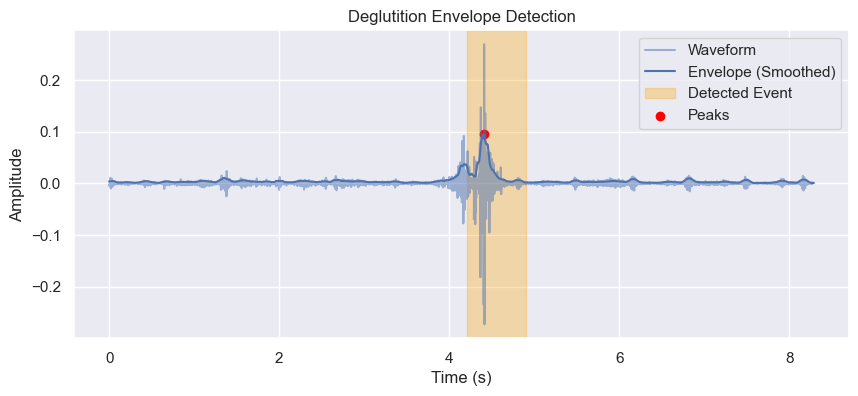

In [12]:
# Load the audio file
audio_path = r"C:\Users\Teresa\Desktop\MBBAS (2ºano)\Tese\Audio_samples\GC-F5-3ml.wav"
y, sr = librosa.load(audio_path, sr=None)

# Set Seaborn style
sns.set(style="darkgrid")

# Compute envelope using the Hilbert transform
analytic_signal = scipy.signal.hilbert(y)
amplitude_envelope = np.abs(analytic_signal)

# Smooth the envelope with a moving average filter
window_size = int(sr * 0.1)  # 100ms window
smoothed_envelope = np.convolve(amplitude_envelope, np.ones(window_size)/window_size, mode='same')

# Detect peaks in the envelope
peaks, _ = scipy.signal.find_peaks(smoothed_envelope, height=np.max(smoothed_envelope) * 0.4, distance=sr*0.8)
peak_times = peaks / sr

# Extract start and end times for each detected event
events = [(max(0, t - 0.2), min(len(y) / sr, t + 0.5)) for t in peak_times]

# Plot waveform and envelope with highlighted event
plt.figure(figsize=(10, 4))
time_axis = np.linspace(0, len(y) / sr, len(y))

sns.lineplot(x=time_axis, y=y, alpha=0.5, label="Waveform")
sns.lineplot(x=time_axis, y=smoothed_envelope, color='b', label="Envelope (Smoothed)")

# Highlight detected events
for start, end in events:
    plt.axvspan(start, end, color='orange', alpha=0.3, label="Detected Event")

# Mark detected peaks
plt.scatter(peak_times, smoothed_envelope[peaks], color='red', label="Peaks")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.title("Deglutition Envelope Detection")
plt.show()


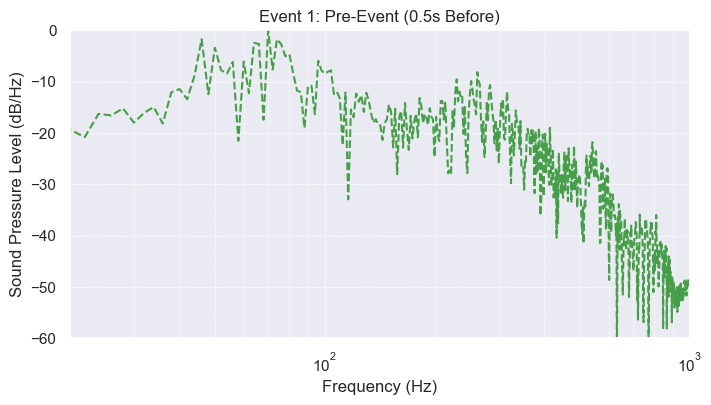

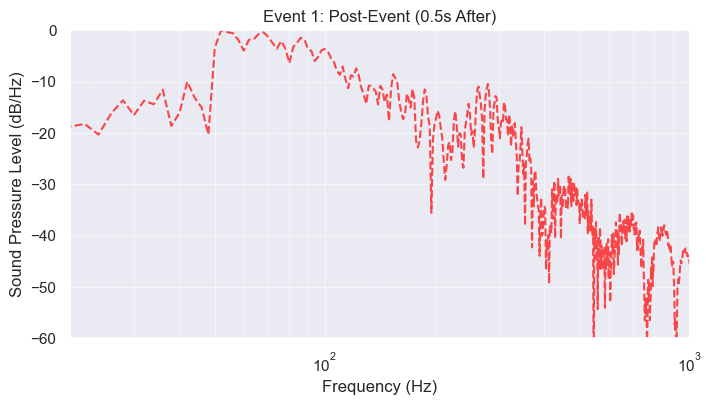

In [14]:
# Load the audio file
audio_path = r"C:\Users\Teresa\Desktop\MBBAS (2ºano)\Tese\Audio_samples\GC-F5-3ml.wav"
y, sr = librosa.load(audio_path, sr=None)

# Compute envelope using Hilbert transform
analytic_signal = scipy.signal.hilbert(y)
amplitude_envelope = np.abs(analytic_signal)

# Smooth the envelope with a moving average filter
window_size = int(sr * 0.1)  # 100ms window
smoothed_envelope = np.convolve(amplitude_envelope, np.ones(window_size)/window_size, mode='same')

# Detect peaks in the envelope
peaks, _ = scipy.signal.find_peaks(smoothed_envelope, height=np.max(smoothed_envelope) * 0.4, distance=sr*0.5)
peak_times = peaks / sr

# ---- Frequency Analysis (Separate Pre & Post Event Plots) ----
for i, peak_time in enumerate(peak_times):
    pre_start_sample = int(max(0, (peak_time - 0.5) * sr))
    pre_end_sample = int(peak_time * sr)
    post_start_sample = int(peak_time * sr)
    post_end_sample = int(min(len(y), (peak_time + 0.5) * sr))

    # Extract pre and post event segments
    pre_event_segment = y[pre_start_sample:pre_end_sample]
    post_event_segment = y[post_start_sample:post_end_sample]

    # Compute FFT for Pre-Event
    N_pre = len(pre_event_segment)
    freq_pre = np.fft.rfftfreq(N_pre, d=1/sr)
    fft_magnitude_pre = np.abs(np.fft.rfft(pre_event_segment))
    fft_magnitude_pre_db = 20 * np.log10(fft_magnitude_pre / np.max(fft_magnitude_pre))

    # Compute FFT for Post-Event
    N_post = len(post_event_segment)
    freq_post = np.fft.rfftfreq(N_post, d=1/sr)
    fft_magnitude_post = np.abs(np.fft.rfft(post_event_segment))
    fft_magnitude_post_db = 20 * np.log10(fft_magnitude_post / np.max(fft_magnitude_post))

    # ---- PLOT Pre-Event ----
    plt.figure(figsize=(8, 4))
    sns.lineplot(x=freq_pre, y=fft_magnitude_pre_db, color='green', linestyle='--', alpha=0.7)
    plt.xscale("log")  # Log frequency scale
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Sound Pressure Level (dB/Hz)")
    plt.title(f"Event {i+1}: Pre-Event (0.5s Before)")
    plt.xlim(20, 1000)  # Limit frequency range
    plt.ylim(-60, 0)  # Dynamic range
    plt.grid(True, which="both", linestyle="--", linewidth=0.5)
    plt.show()

    # ---- PLOT Post-Event ----
    plt.figure(figsize=(8, 4))
    sns.lineplot(x=freq_post, y=fft_magnitude_post_db, color='red', linestyle='--', alpha=0.7)
    plt.xscale("log")  # Log frequency scale
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Sound Pressure Level (dB/Hz)")
    plt.title(f"Event {i+1}: Post-Event (0.5s After)")
    plt.xlim(20, 1000)  # Limit frequency range
    plt.ylim(-60, 0)  # Dynamic range
    plt.grid(True, which="both", linestyle="--", linewidth=0.5)
    plt.show()


GE-F1-3ml

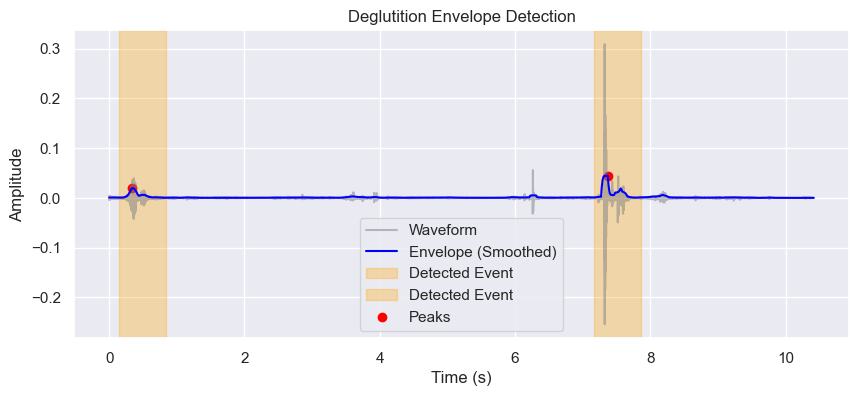

In [15]:
# Load the audio file
audio_path = r"C:\Users\Teresa\Desktop\MBBAS (2ºano)\Tese\Audio_samples\Grupo Estudo\GE_F1_3ML.wav"
y, sr = librosa.load(audio_path, sr=None)

# Compute envelope using Hilbert transform
analytic_signal = scipy.signal.hilbert(y)
amplitude_envelope = np.abs(analytic_signal)

# Smooth the envelope with a moving average filter
window_size = int(sr * 0.1)  # 100ms window
smoothed_envelope = np.convolve(amplitude_envelope, np.ones(window_size)/window_size, mode='same')

# Detect peaks in the envelope
peaks, _ = scipy.signal.find_peaks(smoothed_envelope, height=np.max(smoothed_envelope) * 0.4, distance=sr*0.5)
peak_times = peaks / sr

# Extract start and end times for each detected event
events = [(max(0, t - 0.2), min(len(y) / sr, t + 0.5)) for t in peak_times]

# ---- PLOT WAVEFORM ----
plt.figure(figsize=(10, 4))
time_axis = np.linspace(0, len(y) / sr, len(y))

# Use Seaborn to plot the waveform and the smoothed envelope
sns.lineplot(x=time_axis, y=y, alpha=0.5, label="Waveform", color='gray')  # Waveform in gray
sns.lineplot(x=time_axis, y=smoothed_envelope, label="Envelope (Smoothed)", color='blue')  # Envelope in blue

# Highlight detected events
for start, end in events:
    plt.axvspan(start, end, color='orange', alpha=0.3, label="Detected Event")

# Mark detected peaks using scatter plot (still using matplotlib for scatter)
plt.scatter(peak_times, smoothed_envelope[peaks], color='red', label="Peaks")

# Customize plot labels and title
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.title("Deglutition Envelope Detection")
plt.show()


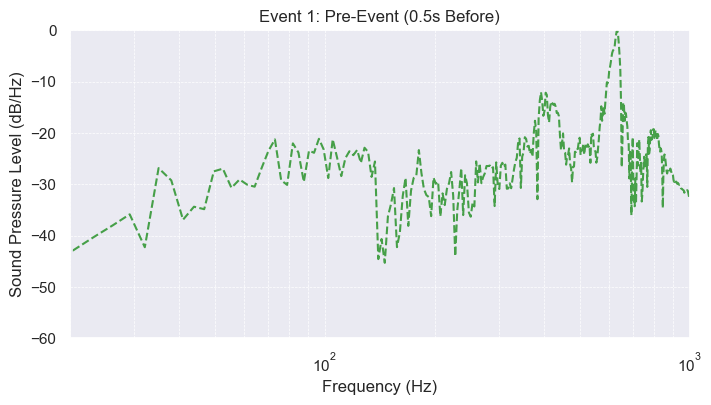

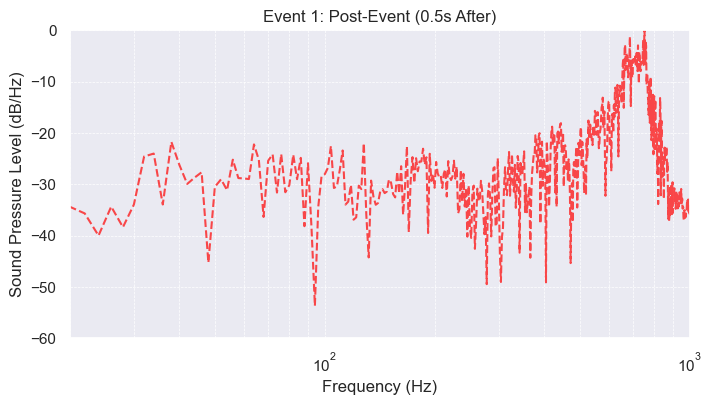

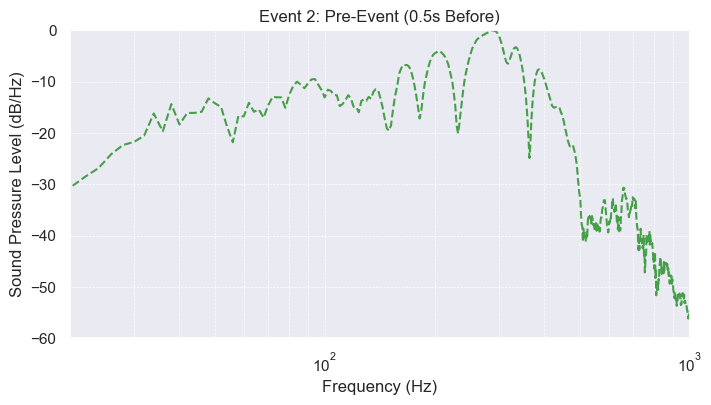

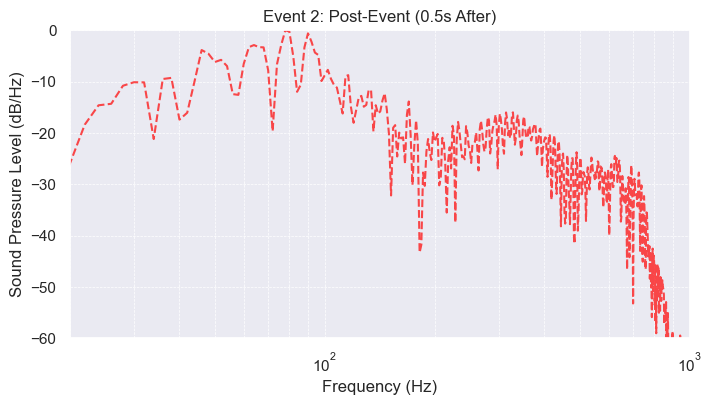

In [16]:
# Load the audio file
audio_path = r"C:\Users\Teresa\Desktop\MBBAS (2ºano)\Tese\Audio_samples\Grupo Estudo\GE_F1_3ML.wav"
y, sr = librosa.load(audio_path, sr=None)

# Compute envelope using Hilbert transform
analytic_signal = scipy.signal.hilbert(y)
amplitude_envelope = np.abs(analytic_signal)

# Smooth the envelope with a moving average filter
window_size = int(sr * 0.1)  # 100ms window
smoothed_envelope = np.convolve(amplitude_envelope, np.ones(window_size)/window_size, mode='same')

# Detect peaks in the envelope
peaks, _ = scipy.signal.find_peaks(smoothed_envelope, height=np.max(smoothed_envelope) * 0.4, distance=sr*0.5)
peak_times = peaks / sr

# ---- Frequency Analysis (Separate Pre & Post Event Plots) ----
for i, peak_time in enumerate(peak_times):
    pre_start_sample = int(max(0, (peak_time - 0.5) * sr))
    pre_end_sample = int(peak_time * sr)
    post_start_sample = int(peak_time * sr)
    post_end_sample = int(min(len(y), (peak_time + 0.5) * sr))

    # Extract pre and post event segments
    pre_event_segment = y[pre_start_sample:pre_end_sample]
    post_event_segment = y[post_start_sample:post_end_sample]

    # Compute FFT for Pre-Event
    N_pre = len(pre_event_segment)
    freq_pre = np.fft.rfftfreq(N_pre, d=1/sr)
    fft_magnitude_pre = np.abs(np.fft.rfft(pre_event_segment))
    fft_magnitude_pre_db = 20 * np.log10(fft_magnitude_pre / np.max(fft_magnitude_pre))

    # Compute FFT for Post-Event
    N_post = len(post_event_segment)
    freq_post = np.fft.rfftfreq(N_post, d=1/sr)
    fft_magnitude_post = np.abs(np.fft.rfft(post_event_segment))
    fft_magnitude_post_db = 20 * np.log10(fft_magnitude_post / np.max(fft_magnitude_post))

    # ---- PLOT Pre-Event ----
    plt.figure(figsize=(8, 4))
    sns.lineplot(x=freq_pre, y=fft_magnitude_pre_db, color='green', linestyle='--', alpha=0.7)  # Green dashed line
    plt.xscale("log")  # Log frequency scale
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Sound Pressure Level (dB/Hz)")
    plt.title(f"Event {i+1}: Pre-Event (0.5s Before)")
    plt.xlim(20, 1000)  # Limit frequency range
    plt.ylim(-60, 0)  # Dynamic range
    plt.grid(True, which="both", linestyle="--", linewidth=0.5)
    plt.show()

    # ---- PLOT Post-Event ----
    plt.figure(figsize=(8, 4))
    sns.lineplot(x=freq_post, y=fft_magnitude_post_db, color='red', linestyle='--', alpha=0.7)  # Red dashed line
    plt.xscale("log")  # Log frequency scale
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Sound Pressure Level (dB/Hz)")
    plt.title(f"Event {i+1}: Post-Event (0.5s After)")
    plt.xlim(20, 1000)  # Limit frequency range
    plt.ylim(-60, 0)  # Dynamic range
    plt.grid(True, which="both", linestyle="--", linewidth=0.5)
    plt.show()
